# Clasificacion de Malformacion de Arnold-Chiari Tipo I
## Notebook 01 — Exploracion del Dataset Raw

Carga y analisis estadistico del dataset crudo en `data/raw/`.

| Clase    | Carpeta            | Etiqueta |
|----------|--------------------|----------|
| Positiva | `data/raw/chiari/` | Chiari-I |
| Negativa | `data/raw/normal/` | Normal   |

In [1]:
import json, random, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
np.random.seed(42)
random.seed(42)

BASE = Path('.').resolve()
DIRS = {
    'chiari'  : BASE / 'data' / 'raw' / 'chiari',
    'normal'  : BASE / 'data' / 'raw' / 'normal',
    'reports' : BASE / 'reports',
    'figures' : BASE / 'reports' / 'figures',
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

EXTENSIONES = {'.jpg', '.jpeg', '.png'}

def listar(carpeta):
    imgs = []
    for ext in EXTENSIONES:
        imgs += list(Path(carpeta).glob(f'*{ext}'))
        imgs += list(Path(carpeta).glob(f'*{ext.upper()}'))
    return sorted(set(imgs))

chiari_raw = listar(DIRS['chiari'])
normal_raw = listar(DIRS['normal'])
print(f'Chiari : {len(chiari_raw)}  |  Normal : {len(normal_raw)}')

Chiari : 126  |  Normal : 30


c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Inventario

In [2]:
registros = []
for ruta, clase, label in (
    [(p, 'chiari', 1) for p in chiari_raw] +
    [(p, 'normal', 0) for p in normal_raw]
):
    try:
        img = Image.open(ruta)
        w, h = img.size
        modo = img.mode
    except Exception:
        w, h, modo = 0, 0, 'ERROR'
    registros.append({
        'ruta'   : str(ruta), 'nombre': ruta.name,
        'clase'  : clase,     'label' : label,
        'ancho'  : w,         'alto'  : h,
        'modo'   : modo,      'kb'    : round(ruta.stat().st_size / 1024, 2),
    })

df = pd.DataFrame(registros)
n0    = int((df.clase == 'normal').sum())
n1    = int((df.clase == 'chiari').sum())
total = len(df)
ratio = n0 / n1 if n1 else 0

print(f'Total : {total}  |  Normal: {n0}  |  Chiari: {n1}  |  Ratio: {ratio:.2f}:1')
print()
print('Modos de color por clase:')
print(df.groupby(['clase', 'modo']).size().rename('n').to_string())
print()
print('Resolucion mas frecuente:')
print(df.groupby(['ancho', 'alto']).size().rename('n').sort_values(ascending=False).head(5).to_string())

Total : 156  |  Normal: 30  |  Chiari: 126  |  Ratio: 0.24:1

Modos de color por clase:
clase   modo
chiari  L       47
        RGB     70
        RGBA     9
normal  L        6
        LA       2
        P        1
        RGB      8
        RGBA    13

Resolucion mas frecuente:
ancho  alto
512    512     47
630    630     26
176    176      7
320    320      5
256    256      4


## 2. Exploracion visual

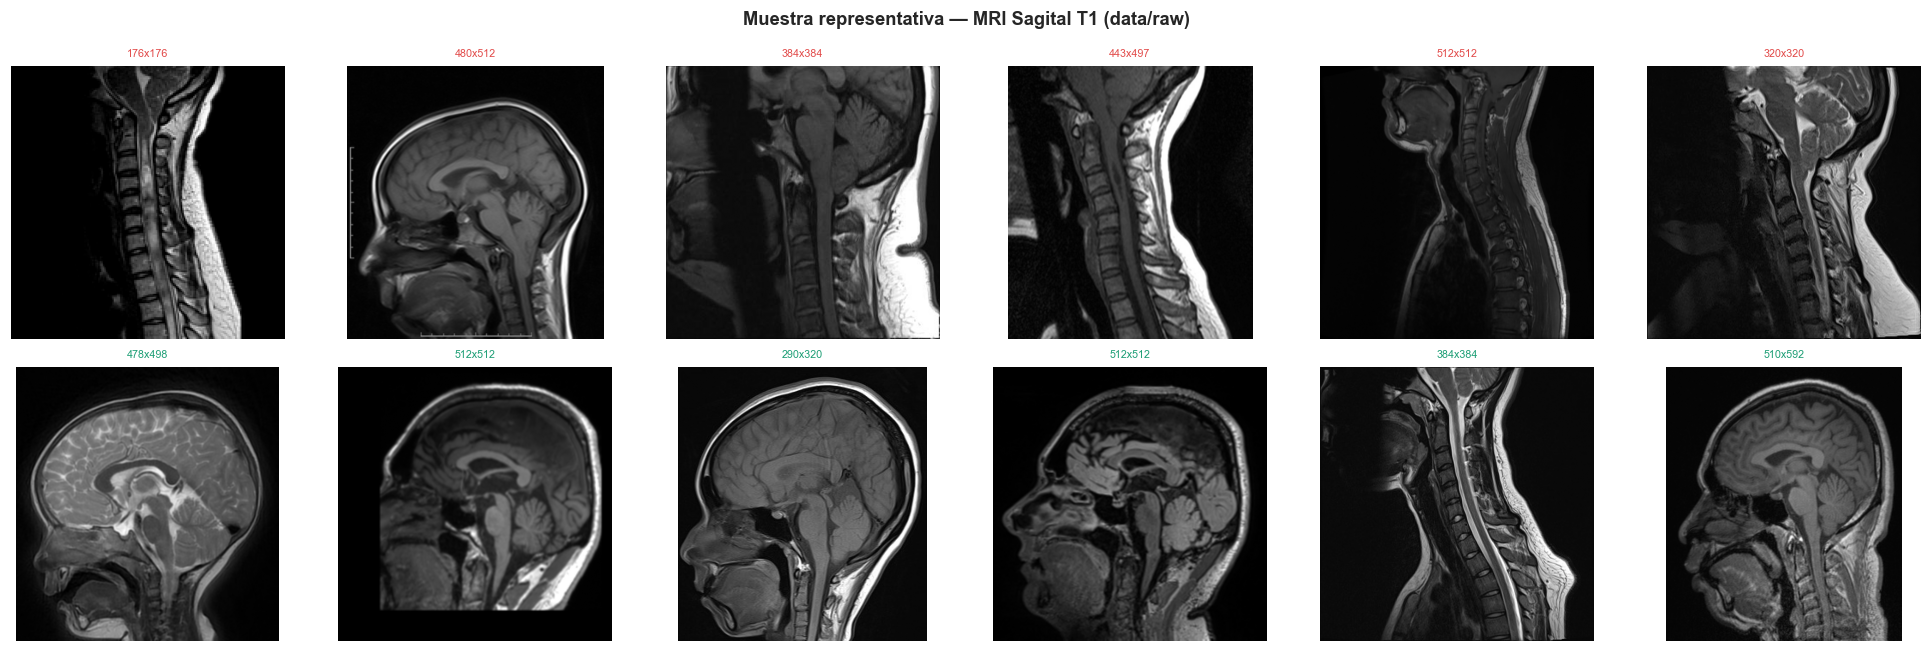

In [3]:
N = 6
fig, axes = plt.subplots(2, N, figsize=(18, 6))
fig.suptitle('Muestra representativa — MRI Sagital T1 (data/raw)',
             fontsize=12, fontweight='bold')

sample_ch = random.sample(chiari_raw, min(N, len(chiari_raw)))
sample_no = random.sample(normal_raw, min(N, len(normal_raw)))
C = {'chiari': '#E24B4A', 'normal': '#1D9E75'}

for i, ruta in enumerate(sample_ch):
    ax = axes[0, i]
    arr = np.array(Image.open(ruta).convert('L'))
    ax.imshow(arr, cmap='gray')
    ax.set_title(f'{arr.shape[1]}x{arr.shape[0]}', fontsize=7, color=C['chiari'])
    ax.axis('off')
axes[0, 0].set_ylabel('Chiari-I', fontsize=10, fontweight='bold', color=C['chiari'])

for i, ruta in enumerate(sample_no):
    ax = axes[1, i]
    arr = np.array(Image.open(ruta).convert('L'))
    ax.imshow(arr, cmap='gray')
    ax.set_title(f'{arr.shape[1]}x{arr.shape[0]}', fontsize=7, color=C['normal'])
    ax.axis('off')
axes[1, 0].set_ylabel('Normal', fontsize=10, fontweight='bold', color=C['normal'])

plt.tight_layout()
plt.savefig(str(DIRS['figures'] / 'muestras_raw.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Analisis estadistico de intensidades

Calculando stats: 100%|██████████| 156/156 [00:01<00:00, 140.31it/s]


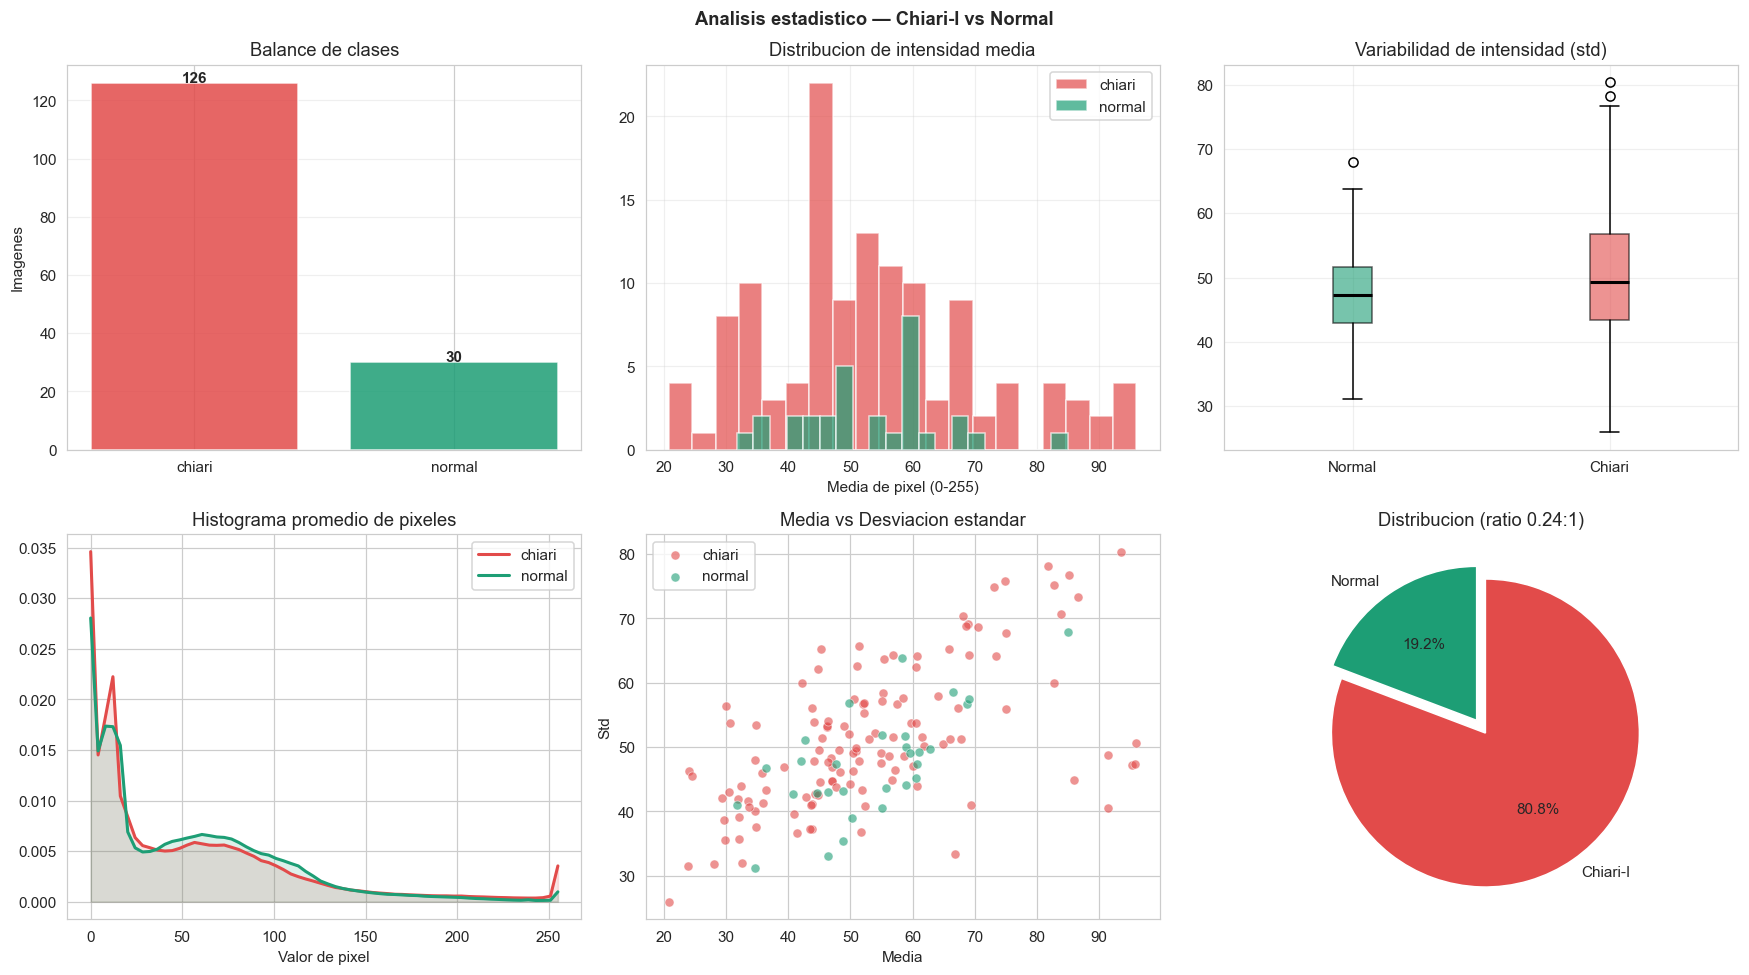

Guardado: reports/figures/dashboard_raw.png


In [4]:
stats = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Calculando stats'):
    try:
        arr = np.array(Image.open(row.ruta).convert('L'), dtype=np.float32)
        stats.append({
            'clase'  : row.clase,
            'media'  : float(arr.mean()),
            'std'    : float(arr.std()),
            'min'    : float(arr.min()),
            'max'    : float(arr.max()),
            'mediana': float(np.median(arr)),
        })
    except Exception:
        pass

df_stats = pd.DataFrame(stats)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Analisis estadistico — Chiari-I vs Normal', fontsize=12, fontweight='bold')

# 1. Balance de clases
ax = axes[0, 0]
cnts = df.clase.value_counts()
bars = ax.bar(cnts.index, cnts.values, color=[C[c] for c in cnts.index], alpha=0.85)
for b, v in zip(bars, cnts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.3, str(v),
            ha='center', fontweight='bold')
ax.set_title('Balance de clases')
ax.set_ylabel('Imagenes')
ax.grid(axis='y', alpha=0.3)

# 2. Distribucion de intensidad media
ax = axes[0, 1]
for clase in ['chiari', 'normal']:
    ax.hist(df_stats[df_stats.clase == clase]['media'], bins=20,
            alpha=0.7, color=C[clase], label=clase, edgecolor='white')
ax.set_title('Distribucion de intensidad media')
ax.set_xlabel('Media de pixel (0-255)')
ax.legend()
ax.grid(alpha=0.3)

# 3. Boxplot std
ax = axes[0, 2]
grupos = [df_stats[df_stats.clase == c]['std'].values for c in ['normal', 'chiari']]
bp = ax.boxplot(grupos, labels=['Normal', 'Chiari'], patch_artist=True,
                medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], [C['normal'], C['chiari']]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_title('Variabilidad de intensidad (std)')
ax.grid(alpha=0.3)

# 4. Histograma promedio de pixeles
ax = axes[1, 0]
for clase in ['chiari', 'normal']:
    rutas = df[df.clase == clase]['ruta'].values[:30]
    hists = [np.histogram(np.array(Image.open(r).convert('L')).flatten(),
                          bins=64, range=(0, 255), density=True)[0]
             for r in rutas]
    hm = np.mean(hists, axis=0)
    bx = np.linspace(0, 255, 64)
    ax.plot(bx, hm, color=C[clase], label=clase, lw=2)
    ax.fill_between(bx, hm, alpha=0.15, color=C[clase])
ax.set_title('Histograma promedio de pixeles')
ax.set_xlabel('Valor de pixel')
ax.legend()

# 5. Media vs Std
ax = axes[1, 1]
for clase in ['chiari', 'normal']:
    sub = df_stats[df_stats.clase == clase]
    ax.scatter(sub['media'], sub['std'], c=C[clase], alpha=0.6,
               label=clase, s=35, edgecolors='white', lw=0.5)
ax.set_title('Media vs Desviacion estandar')
ax.set_xlabel('Media')
ax.set_ylabel('Std')
ax.legend()

# 6. Pie chart
ax = axes[1, 2]
ax.pie([n0, n1], labels=['Normal', 'Chiari-I'],
       colors=[C['normal'], C['chiari']],
       autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05))
ax.set_title(f'Distribucion (ratio {ratio:.2f}:1)')

plt.tight_layout()
plt.savefig(str(DIRS['figures'] / 'dashboard_raw.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: reports/figures/dashboard_raw.png')

## 4. Control de calidad

In [5]:
problemas = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='QC'):
    try:
        arr = np.array(Image.open(row.ruta).convert('L'), dtype=np.float32)
        issues = []
        if arr.max() < 10:
            issues.append('imagen negra (max < 10)')
        if arr.std() < 5:
            issues.append(f'sin varianza (std={arr.std():.1f})')
        if arr.shape[0] < 32 or arr.shape[1] < 32:
            issues.append(f'resolucion muy baja {arr.shape}')
        if issues:
            problemas.append({'archivo': row.nombre, 'clase': row.clase,
                               'problemas': '; '.join(issues)})
    except Exception as e:
        problemas.append({'archivo': row.nombre, 'clase': row.clase,
                          'problemas': str(e)})

print(f'Verificadas   : {len(df)}')
print(f'Validas       : {len(df) - len(problemas)}')
print(f'Con problemas : {len(problemas)}')
if problemas:
    print(pd.DataFrame(problemas).to_string(index=False))
else:
    print('Todas las imagenes pasaron el control de calidad')

QC: 100%|██████████| 156/156 [00:00<00:00, 263.94it/s]

Verificadas   : 156
Validas       : 156
Con problemas : 0
Todas las imagenes pasaron el control de calidad


## 5. Guardado del reporte

In [6]:
df.to_csv(DIRS['reports'] / 'inventario_local.csv', index=False)
df_stats.to_csv(DIRS['reports'] / 'estadisticas_local.csv', index=False)

reporte = {
    'fecha'   : datetime.now().isoformat(),
    'total'   : total,
    'normal'  : n0,
    'chiari'  : n1,
    'ratio'   : round(ratio, 4),
    'validas' : len(df) - len(problemas),
}
with open(DIRS['reports'] / 'reporte_exploracion.json', 'w', encoding='utf-8') as f:
    json.dump(reporte, f, indent=2, ensure_ascii=False)

print('=' * 52)
print('  NOTEBOOK 01 COMPLETADO')
print('=' * 52)
print(f'  Dataset   : {total} imagenes  ({n0} Normal / {n1} Chiari-I)')
print(f'  Ratio     : {ratio:.2f}:1')
print(f'  Validas   : {len(df) - len(problemas)}/{len(df)}')
print()
print('  Reportes: inventario_local.csv, estadisticas_local.csv')
print()
print('  Siguiente: Notebook 02 — Preprocesamiento')
print('=' * 52)

  NOTEBOOK 01 COMPLETADO
  Dataset   : 156 imagenes  (30 Normal / 126 Chiari-I)
  Ratio     : 0.24:1
  Validas   : 156/156

  Reportes: inventario_local.csv, estadisticas_local.csv

  Siguiente: Notebook 02 — Preprocesamiento
